In [1]:
!pip install pandas numpy matplotlib seaborn scikit-learn

In [4]:
# importing the necessary libraries 
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [13]:
# load your dataset 
df=pd.read_csv("Housing.csv")
# display first 5 rows and stats 
print("First 5 rows:")
print(df.head())
print("\nDataset Info:")
print(df.info())
print("\nStatistical Summary:")
print(df.describe())

First 5 rows:
      price  area  bedrooms  bathrooms  stories mainroad guestroom basement  \
0  13300000  7420         4          2        3      yes        no       no   
1  12250000  8960         4          4        4      yes        no       no   
2  12250000  9960         3          2        2      yes        no      yes   
3  12215000  7500         4          2        2      yes        no      yes   
4  11410000  7420         4          1        2      yes       yes      yes   

  hotwaterheating airconditioning  parking prefarea furnishingstatus  
0              no             yes        2      yes        furnished  
1              no             yes        3       no        furnished  
2              no              no        2      yes   semi-furnished  
3              no             yes        3      yes        furnished  
4              no             yes        2       no        furnished  

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 54

In [14]:
# check for missing value 
print("\nMissing Values:")
print(df.isnull().sum())


Missing Values:
price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64


In [15]:
# droping missing value 
df = df.dropna()
print("\nAfter Cleaning Missing Values:")
print(df.isnull().sum())


After Cleaning Missing Values:
price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64


NameError: name 'yes' is not defined

In [17]:
# finding duplicate rows 
print("\nDuplicate Rows:", df.duplicated().sum())

df = df.drop_duplicates()

print("Duplicates after removal:", df.duplicated().sum())


Duplicate Rows: 0
Duplicates after removal: 0


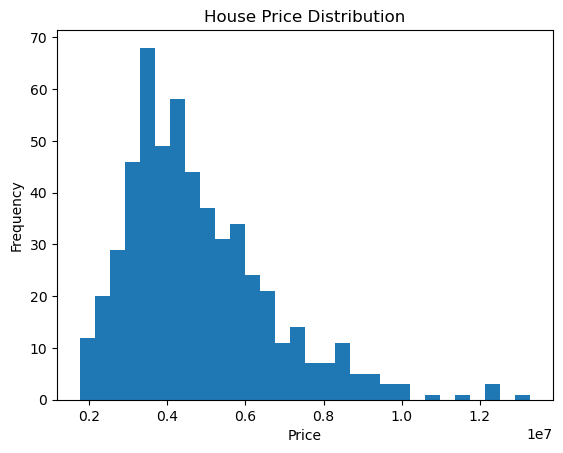

In [18]:
# plotting histogram 
plt.hist(df["price"], bins=30)
plt.title("House Price Distribution")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()


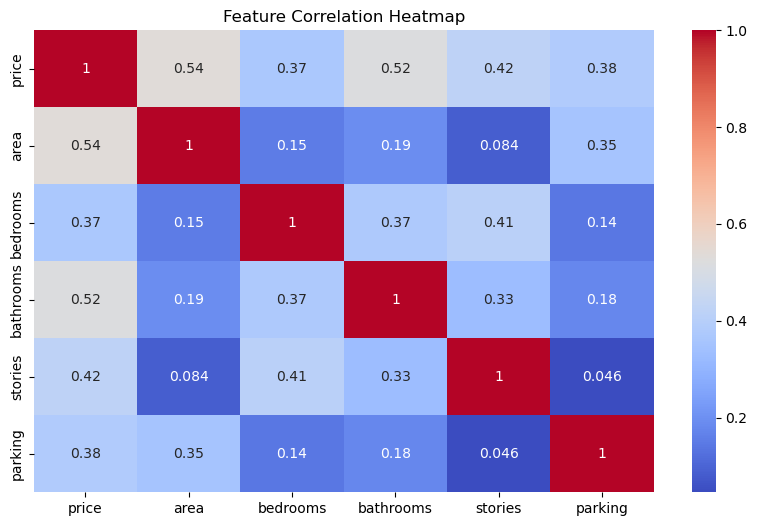

In [19]:
# plotting heatmap 
plt.figure(figsize=(10, 6))

numeric_df = df.select_dtypes(include=[np.number])

sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm")

plt.title("Feature Correlation Heatmap")
plt.show()


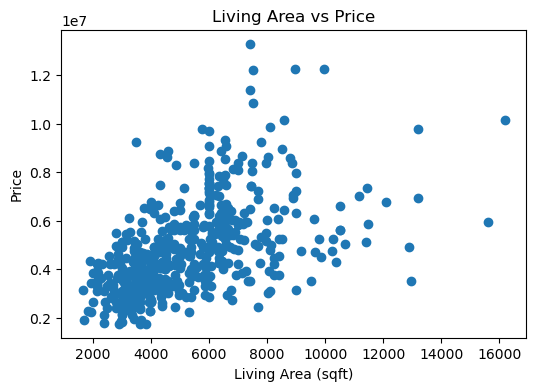

In [21]:
# plotting scatter plot 
plt.figure(figsize=(6, 4))

plt.scatter(df["area"], df["price"])

plt.xlabel("Living Area (sqft)")
plt.ylabel("Price")
plt.title("Living Area vs Price")

plt.show()


In [22]:
# separate features and target 
X = df.drop("price", axis=1)
y = df["price"]

print("\nFeature Columns:")
print(X.columns)

print("\nFeatures Preview:")
print(X.head())

print("\nTarget Preview:")
print(y.head())


Feature Columns:
Index(['area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom',
       'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea',
       'furnishingstatus'],
      dtype='object')

Features Preview:
   area  bedrooms  bathrooms  stories mainroad guestroom basement  \
0  7420         4          2        3      yes        no       no   
1  8960         4          4        4      yes        no       no   
2  9960         3          2        2      yes        no      yes   
3  7500         4          2        2      yes        no      yes   
4  7420         4          1        2      yes       yes      yes   

  hotwaterheating airconditioning  parking prefarea furnishingstatus  
0              no             yes        2      yes        furnished  
1              no             yes        3       no        furnished  
2              no              no        2      yes   semi-furnished  
3              no             yes        3      yes       

In [23]:
# 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

print("\nTraining Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)


Training Data Shape: (436, 12)
Testing Data Shape: (109, 12)


In [24]:
# initializing model 
df_model = df.select_dtypes(include=["int64", "float64"])

print("Numeric columns:")
print(df_model.columns)

Numeric columns:
Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'parking'], dtype='object')


In [25]:
X = df_model.drop("price", axis=1)
y = df_model["price"]

print("\n Features shape:", X.shape)
print(" Target shape:", y.shape)


 Features shape: (545, 5)
 Target shape: (545,)


In [26]:

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

print("\n Data split completed")
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)


 Data split completed
X_train: (436, 5)
X_test: (109, 5)


In [27]:

model = LinearRegression()
model.fit(X_train, y_train)

print("\n Model Training Completed")


 Model Training Completed


In [28]:
# Make predictions on the test set
y_pred = model.predict(X_test)

print("\n Predictions:")
print(y_pred[:5])


 Predictions:
[6178627.50326817 6370140.85865473 3283148.1570249  4226007.94816032
 3409685.55116741]


In [29]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("\n Model Performance Metrics:")
print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R² Score:", r2)
# MAE → Average error
# MSE → Squared error
# RMSE → Error in original units
# R² → Goodness of fit


 Model Performance Metrics:
MAE : 1127483.352323519
MSE : 2292721545725.3613
RMSE: 1514173.552049223
R² Score: 0.5464062355495873


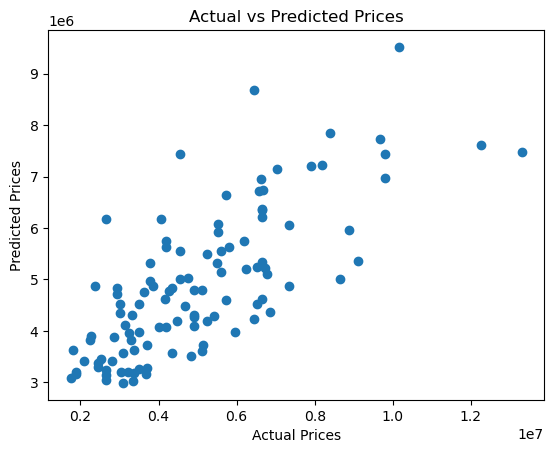

In [30]:
# actual price vs predicted price scatterplot 
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted Prices")
plt.show()